# Individual Project

<div class="alert-info">
<font color="blue">
    
### Big picture: How certain are we about a return statistics-of-interest? 
    
<span style="background-color: #ff9933"><b>* Statistical concept: Randomness, simulation</span>
<br>
<span style="background-color: #ff9933"><b>** Finance concept: Return statistics</span>

Calculating sample statistics estimates (e.g., average, standard deviation, or bivariate statistics such as correlation) is typically straightforward. However, it's also important to assess the confidence level in these sample statistics. For example, the average return of Asset One might appear lower than that of Asset Two, but if the return average of Asset Two varies significantly with the random exclusion of some data points, it suggests lower confidence in this higher sample average. Therefore, drawing conclusions based solely on comparing these two sample averages may not be reliable. In this project, you will engage in a specific "bootstrapping" exercise to determine how (un)certain we are about a return statistics-of-interest. 

<div class="alert-success">
   
### <font color="green">BEGINNING OF SELF-LEARNING</font>   
    
### Notations:
- $N$: number of actual observations given a time series of asset returns; e.g., number of months
- $X$: an original sample of asset returns, $X = (x_1, . . . , x_N)$; for instance, it includes returns in October 2021, November 2021, December 2021 etc.
- $\hat{\theta}_N$: the sample statistics of interest, where $\theta$ can represent <b>mean</b>, <b>standard deviation</b>, <b>correlation</b> or other statistics of interest. The little hat, by statistics standard, typically indicates that it is a sample estimate. See Notebook 1.4a for mathematical expressions for several popular statistics. 


### Bootstrapping:
<span style="background-color: #ffff66">Step 1:</span> In the first round, you will randomly <b>sample with replacement</b> from the original sample $X$, for <span style="background-color: #ffff66">$N$</span> times (notice it's the same $N$ as in the Notations; see above), and call this sample $X_{round=1}$ ("1" stands for first round). Given $X_{round=1}$, you can calculate statistics $\theta$ of interest, and call it $\hat{\theta}_{round=1}$ (1=first round). Record $\hat{\theta}_{round=1}$. 
<br>
<span style="background-color: #ffff66">Step 2:</span> In the second round, you will randomly sample with replacement from the original sample $X$, for $N$ times again, and call this sample $X_{round=2}$ ("2" stands for second round). Given $X_{round=2}$, you can calculate statistics $\theta$ of interest, and call it $\hat{\theta}_{round=2}$ (2=second round). Record $\hat{\theta}_{round=2}$. 
<br>
<span style="background-color: #ffff66">Step 3:</span> Repeat this for $B$ rounds. Each sample that you have created each round, from $X_{round=1}$ to $X_{round=B}$, is a bootstrapped sample. You should obtain $B$ statistics values calculated from these $B$ rounds of bootstrapping. We refer to this procedure as "bootstrapping the original sample for $B$ times". 
    
 
* Note: Again, sample with replacement is not shuffling. Please visit Lecture notebooks 1.3 and 1.4a.    

    
### Bootstrapped standard errors:
You have <span style="background-color: #ffff66">$B$</span> statistics values: \{$\hat{\theta}_{round=1}$, $\hat{\theta}_{round=2}$, ..., $\hat{\theta}_{round=B}$\}. In scientific studies, we can draw a histogram about these statistics, observe how dispersed it looks like, and formally calculate "standard deviation" of \{$\hat{\theta}_{round=1}$, $\hat{\theta}_{round=2}$, ..., $\hat{\theta}_{round=B}$\} to quantify the dispersion. This "standard deviation" is referred to as the bootstrapped standard error of the sample statistics $\hat{\theta}_N$ (obtained from the original sample $X$): SE = SD(\{$\hat{\theta}_{round=1}$, $\hat{\theta}_{round=2}$, ..., $\hat{\theta}_{round=B}$\})
    
* The lower the bootstrapped standard error, the more certain we are about our estimate $\hat{\theta}_N$. 
* Formally, the 95% confidence interval is ($\hat{\theta}_N$ - 1.96\*SE, $\hat{\theta}_N$ + 1.96\*SE). 

### <font color="green">END OF SELF-LEARNING</font>   
 </div>

### Import the data file and obtain sample means, sample standard deviations, and sample correlation between the two series.

In [7]:
import pandas as pd
data_series = pd.read_csv('Nasdaq_vs_DowJones.csv', header=0,parse_dates=True)

Nmean = data_series['NASDAQ'].mean()
Nstd = data_series['NASDAQ'].std()
Dmean = data_series['DJIA'].mean()
Dstd = data_series['DJIA'].std()
original_CORR = data_series['NASDAQ'].corr(data_series['DJIA'])

print('For NASDAQ, the mean is {:.3f}, and the standard deviation is {:.3f}.'.format(Nmean,Nstd))
print('For DowJones, the mean is {:.3f}, and the standard deviation is {:.3f}.'.format(Dmean,Dstd))
print('The correlation between NASDAQ and Dow Jones is {:.3f}.'.format(original_CORR))

For NASDAQ, the mean is 0.013, and the standard deviation is 0.067.
For DowJones, the mean is 0.008, and the standard deviation is 0.043.
The correlation between NASDAQ and Dow Jones is 0.741.


### Obtain the bootstrapped standard error of the correlation statistics between Nasdaq 100 and Dow Jones returns.

 - Given this dataset, $N$ is therefore 516. Note: because you are doing sampling with replacement for 516 times from the same original sample, you may get a number being drawn twice into one bootstrapped sample.
 - Let's assume $B$ = 5000. 


In [5]:
%matplotlib inline
import random
import math
import matplotlib.pyplot as plt
import numpy as np


Ndata = data_series['NASDAQ']
Ddata = data_series['DJIA']
B = 5000

paired = list(zip(Ndata, Ddata)) #make the 2 data series into tuples, and then a list of tuples
corr = []

for i in range(0, B):
    draw = random.choices(paired, k=516) #bootstrapping, take 516 pairs each time
    Cn, Cd = zip(*draw)
    CORR = np.corrcoef(Cn, Cd)[0, 1]#calculate the corr for each pair of Cn,Cd
    corr.append(CORR) #collect the correlations

corr_series = pd.Series(corr)#turn the list into series
corr_std = corr_series.std()

print('The bootstrapped standard error of the correlation statistics between Nasdaq 100 and Dow Jones returns is {:.3f}.'.format(corr_std))

The bootstrapped standard error of the correlation statistics between Nasdaq 100 and Dow Jones returns is 0.030.


### Produce and plot time-varying 95% confidence interval of correlations.

* Let's use 45-month rolling window.
* How to compute 95% confidence interval? You know it. With correlation sample estimate and its bootstrapped SE, you can produce the 95% confidence interval: [correlation-1.96\*SE, correlation+1.96\*SE]. 
* Here, you produce one correlation estimate and one SE within one rolling window. Record, and the move onto the next rolling window. 

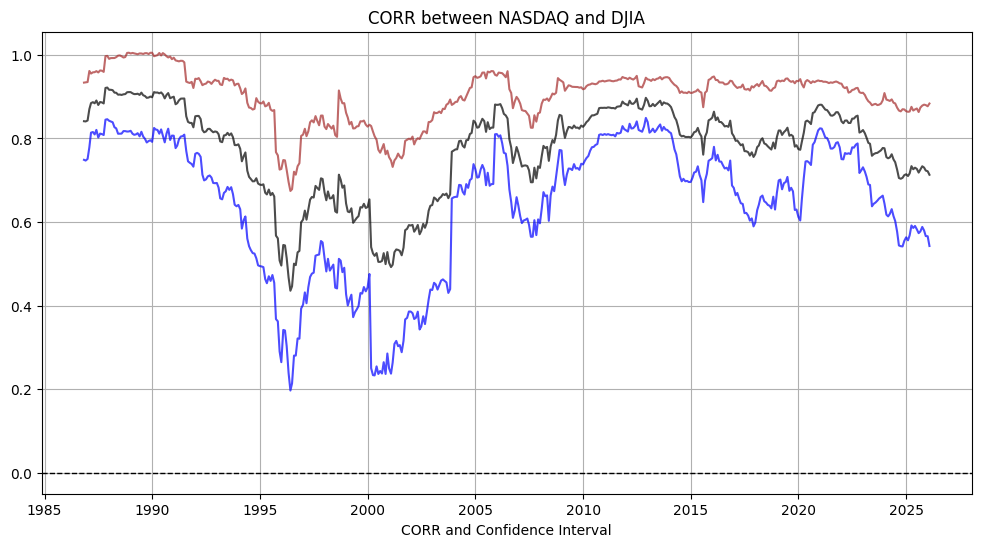

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

data_series['yyyymm'] = pd.to_datetime(data_series['yyyymm'])
#data_series = data_series.set_index('yyyymm')

rolling_corr = Ndata.rolling(window=45).corr(Ddata).dropna()#original rolling corr
time_varying_SE = []

paired = list(zip(Ndata, Ddata)) #make the 2 data series into tuples, and then a list of tuples

for roll in range(45, len(Ndata)+1):
    rolling_corr_temp = paired[roll-45:roll] #rolling
    time_varying_corr = []
    for i in range(0, 5000):
        draw = random.choices(rolling_corr_temp, k=45)
        cN, cD = zip(*draw)
        CORR = np.corrcoef(cN, cD)[0, 1]#calculate the corr for each pair of cN,cD
        time_varying_corr.append(CORR) #bootstrapping simulation:correlations
    
    current_SE = np.std(time_varying_corr, ddof=1) 
    time_varying_SE.append(current_SE) #boostrapping: correlation SE
        
cr_left = []
cr_right = []

for i in range(0, len(time_varying_SE)):#creating data list of confidence interval
    cr_left.append(rolling_corr.iloc[i] - 1.96 * time_varying_SE[i])
    cr_right.append(rolling_corr.iloc[i] + 1.96 * time_varying_SE[i])

cr_left_series = pd.Series(cr_left, index=rolling_corr.index)
cr_right_series = pd.Series(cr_right, index=rolling_corr.index)
#--------------
plt.figure(figsize=(12, 6))
plt.plot(data_series['yyyymm'].iloc[44:], rolling_corr, linestyle='-', marker=None, color='black', alpha=0.7)
plt.plot(data_series['yyyymm'].iloc[44:], cr_left_series, linestyle='-', marker=None, color='blue', alpha=0.7)
plt.plot(data_series['yyyymm'].iloc[44:], cr_right_series, linestyle='-', marker=None, color='brown', alpha=0.7)
plt.xlabel("CORR and Confidence Interval")
plt.title("CORR between NASDAQ and DJIA")
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)  # Add a reference line at zero
plt.grid(True)
plt.savefig('CORR between NASDAQ and DJIA.jpg')  
plt.show()


### Findings

From the results, we can notice that the correlation between NASDAQ and DJIA remains high during stable periods. However, significant deviations occur during major market shifts. As shown in the figure, a notable drop in correlation happened during the Dot-com bubble (1995-2000), as tech stocks (NASDAQ) deviated from traditional industries (DJIA). Conversely, during the 2008 Financial Crisis, systematic risk became the main driver; Everyone just wanted cash, which caused both indices to move in the same direction, keeping the correlation high.